# Ottimizzazione del dispacciamento dell'accumulo a batteria per arbitraggio energetico e peak shaving

## Sintesi esecutiva

Un sito commerciale connesso alla rete gestisce una batteria agli ioni di litio da 2 MW / 8 MWh insieme a un carico elettrico misurato. Il sito viene fatturato in due modi: un **prezzo dell'energia** orario del mercato del giorno prima ($/MWh) e un **onere di potenza** mensile sul suo singolo intervallo di prelievo dalla rete più elevato ($/MW). Il gestore dell'asset deve decidere, ora per ora, quando caricare la batteria (acquistando energia a basso costo e aumentando il prelievo dalla rete) e quando scaricarla (compensando l'energia costosa e riducendo il prelievo dalla rete). Due flussi di valore competono: l'**arbitraggio energetico** (acquistare a basso costo di notte, scaricare al picco serale) e il **peak shaving** (limitare il massimo di rete fatturato). La carica non è gratuita — l'efficienza di ciclo completo comporta la perdita di circa il 10% dell'energia immagazzinata — quindi la pianificazione è una vera ottimizzazione, non un'euristica.

Questo notebook costruisce la decisione dall'inizio alla fine. Innanzitutto sintetizza una curva di prezzo realistica del giorno prima su 24 ore (con picchi mattutini e serali più un minimo notturno) e un profilo di carico del sito correlato, quindi profila entrambi con **PROC MEANS** e una robusta banda di prezzo ai percentili 2,5/97,5 con **PROC UNIVARIATE**. Il nucleo è un programma lineare in **PROC OPTMODEL**: variabili decisionali per carica, scarica e stato di carica orari, più una variabile di picco fatturato, soggette a un bilancio cumulativo dello stato di carica (con efficienza di carica/scarica separata), limiti di potenza e capacità, e un vincolo di definizione del picco. La funzione obiettivo massimizza il margine di arbitraggio al netto dell'onere di potenza. **PROC SQL** quantifica poi il costo di riferimento rispetto a quello ottimizzato, e tre pannelli **PROC SGPLOT** visualizzano la pianificazione di carica/scarica rispetto al prezzo, la traiettoria dello stato di carica e il profilo appiattito di prelievo dalla rete.

**Risultato sulla giornata sintetica:** l'ottimizzatore riempie la batteria durante le ore notturne più economiche, scarica sia nel picco di prezzo mattutino sia in quello serale, ricarica durante la valle di prezzo di metà giornata e — cosa cruciale — trattiene la propria potenza di carica in modo da non creare mai un nuovo picco di rete. Il costo energetico giornaliero scende da **\$2.903,78 a \$2.528,43** — **\$375,34 (12,9%) di risparmio da arbitraggio** — mentre il massimo di rete fatturato scende da **3,59 MW a 3,43 MW** (circa **0,16 MW**), del valore di ulteriori **\$18,98** all'onere di potenza a quota giornaliera assunta. Lo stesso modello si adatta a orizzonti più lunghi, a scenari di prezzo multipli o a una ciclatura consapevole del degrado semplicemente estendendo l'insieme degli indici e i vincoli.

## Fonti dei dati

Tutti i dati sono **sintetici**, generati inline nella prima cella di codice con `CALL STREAMINIT(20260605)` per la riproducibilità. Nessun file esterno o accesso di rete. Un unico dataset, `price_load`, con 24 righe orarie che rappresentano una singola giornata operativa.

| Variabile | Tipo | Unità | Descrizione |
|----------|------|-------|-------------|
| `hour` | num | 0–23 | Ora della giornata operativa (indice dell'orizzonte) |
| `price` | num | $/MWh | Prezzo dell'energia del giorno prima: minimo notturno, picchi mattutino + serale, con rumore gaussiano (limitato inferiormente a $5) |
| `load` | num | MW | Domanda elettrica del sito, correlata all'attività giornaliera (limitata inferiormente a 0,3 MW) |
| `day_type` | char | — | Flag della finestra tariffaria: `PeakTOU` (ore 17–21) vs `OffPeak`, usato per il riepilogo dello spread di prezzo picco/fuori picco |

I parametri della batteria sono costanti fisse del modello all'interno di PROC OPTMODEL: 8 MWh di capacità utilizzabile, 2 MW di potenza massima di carica/scarica, 0,95 di efficienza di carica e 0,95 di efficienza di scarica (~90% di ciclo completo), stato di carica iniziale 0 MWh, e un onere di potenza di \$120/MW applicato al picco di rete fatturato della giornata (la quota giornaliera ammortizzata di un onere di potenza mensile).

# Ottimizzazione del dispacciamento dell'accumulo a batteria
## Arbitraggio energetico e peak shaving per un sito connesso alla rete

Un sito commerciale gestisce una **batteria da 2 MW / 8 MWh** a valle del suo contatore. La sua bolletta elettrica ha due componenti: un **prezzo dell'energia** orario ($/MWh) e un **onere di potenza** mensile sul singolo intervallo di prelievo dalla rete più elevato ($/MW). L'operatore desidera una pianificazione oraria di carica/scarica che catturi due flussi di valore contemporaneamente:

- **Arbitraggio** — immagazzinare energia notturna a basso costo, rilasciarla durante le costose ore di picco.
- **Peak shaving** — scaricare durante il picco di domanda per abbassare il massimo di rete fatturato.

Poiché l'efficienza di ciclo completo perde circa il 10% dell'energia immagazzinata, il compromesso non è banale e giustifica una vera ottimizzazione. Lo formuliamo come programma lineare in **PROC OPTMODEL**, quindi ne quantifichiamo e visualizziamo il risultato.

> Tutti i dati sottostanti sono sintetici e generati inline — il notebook è completamente autonomo e viene eseguito in pochi secondi.

## 1. Generare un profilo sintetico di prezzo e carico del giorno prima

Costruiamo una giornata operativa (24 righe orarie). La curva di prezzo ha un minimo notturno e picchi mattutino + serale; il carico del sito è correlato all'attività giornaliera. Un seme fisso mantiene l'esecuzione riproducibile. Inoltre etichettiamo la finestra di picco time-of-use prevista dalla normativa in modo da poter riepilogare in seguito lo spread picco/fuori picco.

In [1]:
DATI price_load;
    CHIAMARE streaminit(20260605);
    LUNGHEZZA day_type $12;
    FARE hour = 0 FINO_A 23;
        /* Prezzo diurno dell'energia ($/MWh): picchi mattutino + serale */
        BASE = 38
             + 26 * EXP(-((hour - 8)**2) / 6)
             + 40 * EXP(-((hour - 19)**2) / 5)
             - 14 * EXP(-((hour - 3)**2) / 8);
        price = round(BASE + rand('normal', 0, 4), 0.01);
        SE_COND price < 5 ALLORA price = 5;

        /* Carico del sito (MW): minimo notturno, rampa serale */
        LOAD = round(2.0
             + 1.6 * EXP(-((hour - 19)**2) / 7)
             + 0.7 * EXP(-((hour - 9)**2) / 10)
             + rand('normal', 0, 0.10), 0.01);
        SE_COND LOAD < 0.3 ALLORA LOAD = 0.3;

        SE_COND hour >= 17 E_LOG hour <= 21 ALLORA day_type = 'Punta';
        ALTRIMENTI day_type = 'Fuori punta';
        USCITA;
    FINE;
    RIMUOVERE BASE;
ESEGUIRE;



NOTE: DATA price_load


NOTE: Wrote price_load (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Profilare le distribuzioni di prezzo e carico

Prima di ottimizzare, verifichiamo la coerenza degli input. Lo spread tra le ore più economiche e più costose è ciò che l'arbitraggio monetizza, e il carico massimo àncora l'opportunità di peak shaving.

In [2]:
PROCEDURA MEDIE DATI=price_load n mean std MIN MAX maxdec=2;
    VARIABILE price LOAD;
    ETICHETTA price = 'Prezzo ($/MWh)'
          LOAD  = 'Carico (MW)';
    TITOLO 'Statistiche riassuntive di prezzo e carico';
ESEGUIRE;


                                       Statistiche riassuntive di prezzo e carico                                       

                                                  The MEANS Procedure

 Variable  Label                 N        Mean     Std Dev     Minimum     Maximum
 ---------------------------------------------------------------------------------
 price     Prezzo ($/MWh)       24       46.29       15.81       18.57       79.27
 LOAD      Carico (MW)          24        2.47        0.48        1.71        3.59
 ---------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Spread di prezzo picco vs fuori picco

Il raggruppamento in base al flag time-of-use mostra quanto siano più ricche le ore di picco rispetto alla base fuori picco — il segnale strutturale che la batteria sfrutta.

In [3]:
PROCEDURA MEDIE DATI=price_load mean MIN MAX maxdec=2;
    CLASSE day_type;
    VARIABILE price;
    ETICHETTA day_type = 'Fascia tariffaria'
          price    = 'Prezzo ($/MWh)';
    TITOLO 'Prezzo per fascia tariffaria';
ESEGUIRE;


                                              Prezzo per fascia tariffaria                                              

                                                  The MEANS Procedure

                                       Analysis Variable : price Prezzo ($/MWh)

                                                    N
                             Fascia tariffaria    Obs       Mean      Minimum      Maximum
                             -------------------------------------------------------------
                             Fuori punta           19      40.46        18.57        54.89
                             Punta                  5      68.45        54.88        79.27
                             -------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 4. Banda di prezzo robusta (percentili 2,5 / 97,5)

Caratterizziamo le code dei prezzi con una banda ai percentili 2,5 / 97,5. **PROC UNIVARIATE** con `PCTLPTS=` calcola in modo pulito percentili arbitrari, ovvero lo strumento corretto per i percentili frazionari.

In [4]:
PROCEDURA UNIVARIATE DATI=price_load NOPRINT;
    VARIABILE price;
    USCITA out=price_band pctlpts=2.5 97.5 pctlpre=p_;
ESEGUIRE;

PROCEDURA STAMPARE DATI=price_band noobs ETICHETTA;
    ETICHETTA p_2_5  = 'Prezzo al 2,5° percentile ($/MWh)'
          p_97_5 = 'Prezzo al 97,5° percentile ($/MWh)';
    TITOLO 'Banda di prezzo: percentili 2,5 e 97,5';
ESEGUIRE;


                                         Banda di prezzo: percentili 2,5 e 97,5                                         

 Prezzo al 2,5° percentile ($/MWh)   Prezzo al 97,5° percentile ($/MWh)
                             18.57                                79.27




NOTE: PROC UNIVARIATE
NOTE: Output dataset price_band has 1 observations and 2 variables.
NOTE: PROC PRINT data=price_band

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 5. L'ottimizzazione del dispacciamento (programma lineare)

Leggiamo il prezzo e il carico orari in PROC OPTMODEL e dichiariamo:

- `chg[h]`, `dis[h]` — potenza oraria di carica / scarica (MW), limitata dalla potenza dell'inverter di 2 MW.
- `soc[h]` — stato di carica (MWh), limitato dalla capacità utilizzabile di 8 MWh.
- `peak` — il massimo di rete fatturato (MW).

**Vincoli.** `soc_balance` accumula l'energia netta attraverso ogni ora con efficienza di carica/scarica separata (una forma a somma progressiva della ricorrenza oraria). `peak_def` obbliga `peak` a dominare il prelievo netto dalla rete di ogni ora, così che minimizzarlo riduca l'onere di potenza.

**Obiettivo.** Massimizzare il margine di arbitraggio — `price × (discharge − charge)` sommato sulla giornata — meno l'onere di potenza sul picco fatturato. Risolviamo come LP continuo.

In [5]:
PROCEDURA optmodel;
    IMPOSTARE HOURS;
    num price{HOURS};
    num LOAD{HOURS};

    READ DATI price_load INTO HOURS=[hour]
        price=price col=price
        LOAD=LOAD col=LOAD;

    /* Batteria: 8 MWh utili, 2 MW di potenza, ~90% efficienza andata-ritorno */
    num capacity   = 8.0;
    num p_max      = 2.0;
    num eta_chg    = 0.95;
    num eta_dis    = 0.95;
    num soc0       = 0.0;
    num dt         = 1.0;
    /* Onere di potenza applicato al picco di rete fatturato del giorno ($/MW).
       Gli oneri di potenza commerciali sono mensili; 120 e' il valore marginale
       di ridurre il massimo di rete odierno una volta che l'onere mensile e'
       ammortizzato sulla giornata. E' abbastanza grande da indurre l'ottimizzatore
       a trattenere la potenza di carica invece di creare un nuovo picco piu' alto. */
    num demand_chg = 120;

    /* Variabili decisionali (MW carica / scarica, MWh stato di carica) */
    VARIABILE chg{HOURS}  >= 0 <= p_max;
    VARIABILE dis{HOURS}  >= 0 <= p_max;
    VARIABILE soc{HOURS}  >= 0 <= capacity;
    VARIABILE peak        >= 0;   /* picco di rete fatturato (MW) per l'onere di potenza */

    /* Prelievo netto dalla rete dopo l'azione della batteria (MW) */
    impvar grid_mw{h IN HOURS} = LOAD[h] + chg[h] - dis[h];

    /* Stato di carica cumulativo: energia entrante meno uscente fino all'ora h,
       con efficienza di carica/scarica applicata. Equivale a una ricorrenza
       oraria ma espressa come somma progressiva sulle ore precedenti. */
    con soc_balance{h IN HOURS}:
        soc[h] = soc0
                 + sum{k IN HOURS: k <= h}
                     (eta_chg * chg[k] - dis[k] / eta_dis) * dt;

    /* Peak shaving: il picco fatturato e' il massimo prelievo di rete della giornata */
    con peak_def{h IN HOURS}: peak >= grid_mw[h];

    /* Massimizza il margine di arbitraggio energetico al netto dell'onere di potenza */
    MAX net_value =
        sum{h IN HOURS} price[h] * (dis[h] - chg[h]) * dt
        - demand_chg * peak;

    solve WITH lp;

    CREARE DATI dispatch FROM [hour=HOURS]
        price=price[hour]
        LOAD=LOAD[hour]
        charge_mw=chg[hour]
        discharge_mw=dis[hour]
        soc_mwh=soc[hour]
        grid_mw=grid_mw[hour];
QUIT;


                                         Banda di prezzo: percentili 2,5 e 97,5                                         


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Maximization
  Objective Function            NET_VALUE
  Objective Type                Linear

  Number of Variables           73
  Bounded Above                 0
  Bounded Below                 1
  Bounded Below and Above       72
  Free                          0
  Fixed                         0

  Number of Constraints         48

                          Solution Summary
  Solver                        LP
  Objective Function            NET_VALUE
  Solution Status               Optimal
  Objective Value               -36.4771665526




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 6. La pianificazione oraria ottimale

La tabella risolta mostra la carica distribuita nelle economiche ore notturne e di metà giornata — moderata a circa 1,0–1,7 MW in modo da non stabilire mai un nuovo picco di rete — la scarica concentrata nei picchi di prezzo mattutino e serale, e lo stato di carica che traccia un ragionevole ciclo di riempimento e rilascio entro il tetto di 8 MWh. La colonna `grid_mw` mantiene un tetto piatto di circa 3,43 MW attraverso ogni ora di carica, la firma del vincolo di picco vincolante.

In [6]:
PROCEDURA STAMPARE DATI=dispatch noobs ETICHETTA;
    VARIABILE hour price LOAD charge_mw discharge_mw soc_mwh grid_mw;
    ETICHETTA hour        = 'Ora'
          price       = 'Prezzo ($/MWh)'
          LOAD        = 'Carico (MW)'
          charge_mw   = 'Carica (MW)'
          discharge_mw= 'Scarica (MW)'
          soc_mwh     = 'Stato di carica (MWh)'
          grid_mw     = 'Prelievo dalla rete (MW)';
    TITOLO 'Piano orario di dispacciamento della batteria';
ESEGUIRE;


                                     Piano orario di dispacciamento della batteria                                      

Ora  Prezzo ($/MWh)  Carico (MW)  Carica (MW)  Scarica (MW)  Stato di carica (MWh)  Prelievo dalla rete (MW)
  0           29.73         1.99    1.4418421             0                1.36975                 3.4318421
  1           28.03         2.16    1.2718421             0                  2.578                 3.4318421
  2           21.87            2    1.4318421             0                3.93825                 3.4318421
  3           18.57         1.71    1.7218421             0                  5.574                 3.4318421
  4           27.62         2.13    1.3018421             0                6.81075                 3.4318421
  5           36.12         2.18    1.2518421             0                      8                 3.4318421
  6           50.37         2.32            0             0                      8                      2.32
  7   


NOTE: PROC PRINT data=dispatch

NOTE: PROC PRINT completed: 24 observations printed, 7 variables


## 7. KPI principali: riferimento vs ottimizzato

Confrontiamo il riferimento inattivo (pagare il prezzo per il carico grezzo ogni ora) con la posizione di rete ottimizzata, e riportiamo il risparmio da arbitraggio, la riduzione del picco fatturato e il valore in dollari di tale riduzione all'onere di potenza — le due leve che guidano il business case.

In [7]:
PROCEDURA SQL;
    CREARE TABELLA kpi AS
    SELEZIONARE
        sum(price * LOAD)                        AS base_energy_cost,
        sum(price * grid_mw)                     AS opt_energy_cost,
        sum(price * LOAD) - sum(price * grid_mw) AS arbitrage_savings,
        MAX(LOAD)                                AS base_peak_mw,
        MAX(grid_mw)                             AS opt_peak_mw,
        MAX(LOAD) - MAX(grid_mw)                 AS peak_reduction_mw,
        120 * (MAX(LOAD) - MAX(grid_mw))         AS demand_charge_savings
    FROM dispatch;
QUIT;

PROCEDURA STAMPARE DATI=kpi noobs ETICHETTA;
    ETICHETTA base_energy_cost     = 'Costo energia base ($)'
          opt_energy_cost      = 'Costo energia ottimizzato ($)'
          arbitrage_savings    = 'Risparmio da arbitraggio ($)'
          base_peak_mw         = 'Picco base (MW)'
          opt_peak_mw          = 'Picco ottimizzato (MW)'
          peak_reduction_mw    = 'Riduzione del picco (MW)'
          demand_charge_savings= 'Risparmio su oneri di potenza ($)';
    TITOLO 'Indicatori chiave: arbitraggio e riduzione del picco';
ESEGUIRE;


                                     Piano orario di dispacciamento della batteria                                      

                                  Indicatori chiave: arbitraggio e riduzione del picco                                  

Costo energia base ($)  Costo energia ottimizzato ($)  Risparmio da arbitraggio ($)  Picco base (MW)  Picco ottimizzato (MW)  Riduzione del picco (MW)  Risparmio su oneri di potenza ($)
             2903.7774                2528.4335145526                375.3438854474             3.59               3.4318421                 0.1581579                          18.978948




NOTE: PROC SQL 

NOTE: Table kpi created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=kpi

NOTE: PROC PRINT completed: 1 observations printed, 7 variables


## 8. Pianificazione di carica / scarica rispetto al prezzo

La carica (aghi blu) e la scarica (linea rossa con marcatori) condividono l'asse dei megawatt a sinistra; il prezzo del giorno prima (verde tratteggiato) si legge a destra. La carica si concentra nelle economiche ore notturne e di metà giornata, mentre la scarica si attiva nei picchi di prezzo mattutino e serale — la visualizzazione conferma che l'ottimizzatore acquista a basso costo e vende a prezzo alto.

                                  Indicatori chiave: arbitraggio e riduzione del picco                                  




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


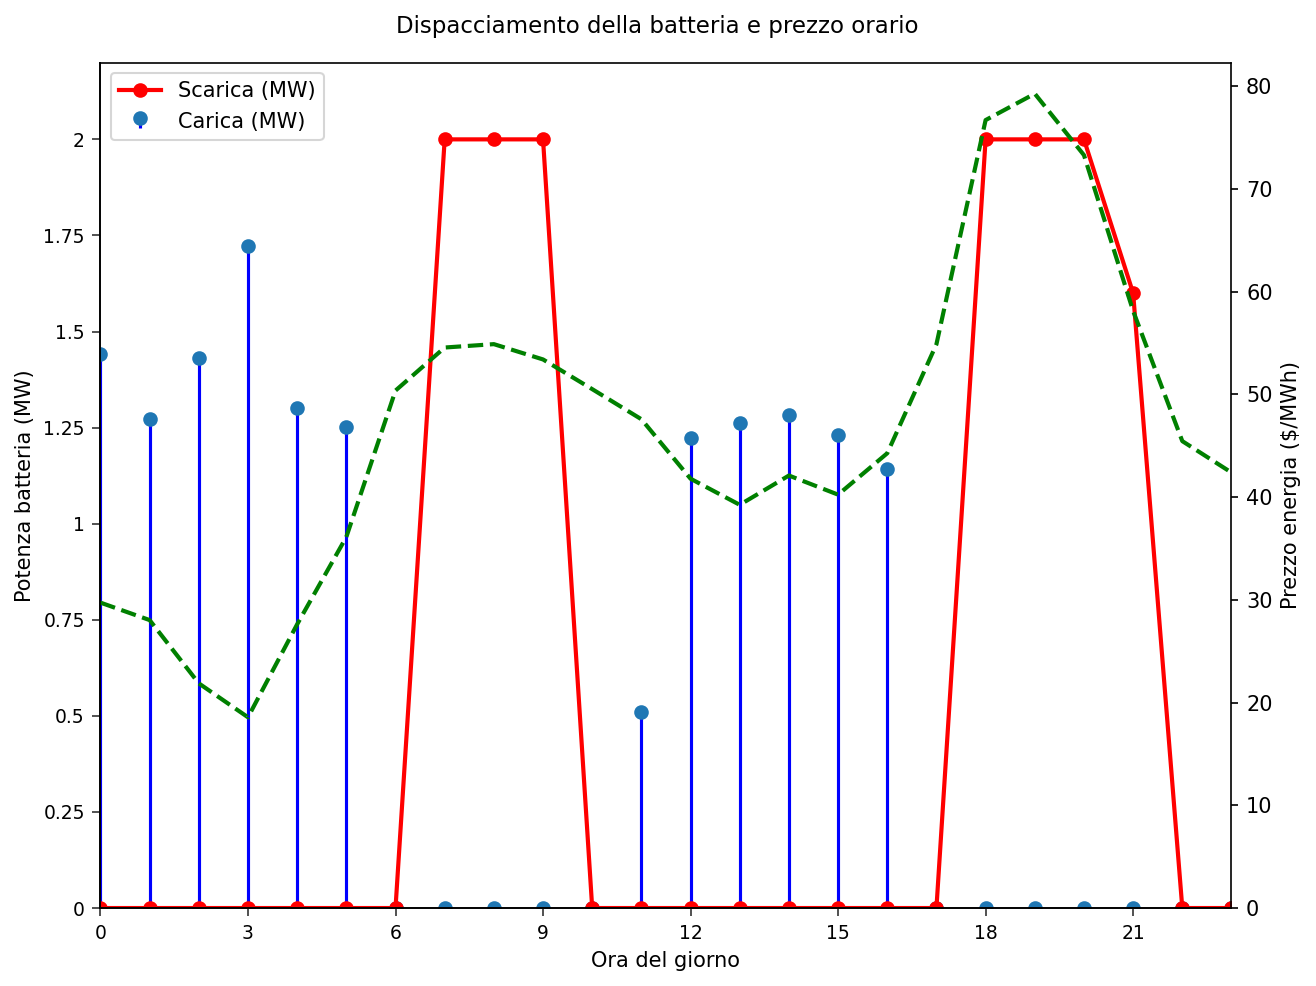

In [8]:
PROCEDURA SGPLOT DATI=dispatch;
    needle x=hour y=charge_mw / LINEATTRS=(color=blue thickness=3)
        legendlabel="Carica (MW)";
    SERIES x=hour y=discharge_mw / LINEATTRS=(color=red thickness=2)
        MARKERS legendlabel="Scarica (MW)";
    SERIES x=hour y=price / y2axis LINEATTRS=(color=green pattern=dash thickness=2)
        legendlabel="Prezzo ($/MWh)";
    XAXIS ETICHETTA="Ora del giorno" VALUES=(0 FINO_A 23 PER 3);
    YAXIS ETICHETTA="Potenza batteria (MW)" MIN=0 MAX=2.2;
    y2axis ETICHETTA="Prezzo energia ($/MWh)" MIN=0;
    TITOLO "Dispacciamento della batteria e prezzo orario";
ESEGUIRE;


## 9. Traiettoria dello stato di carica

L'energia immagazzinata cresce mentre la batteria si riempie di notte, si esaurisce attraverso ogni finestra di scarica e non supera mai il tetto di capacità utilizzabile di 8 MWh (riferimento punteggiato).

                                  Indicatori chiave: arbitraggio e riduzione del picco                                  




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


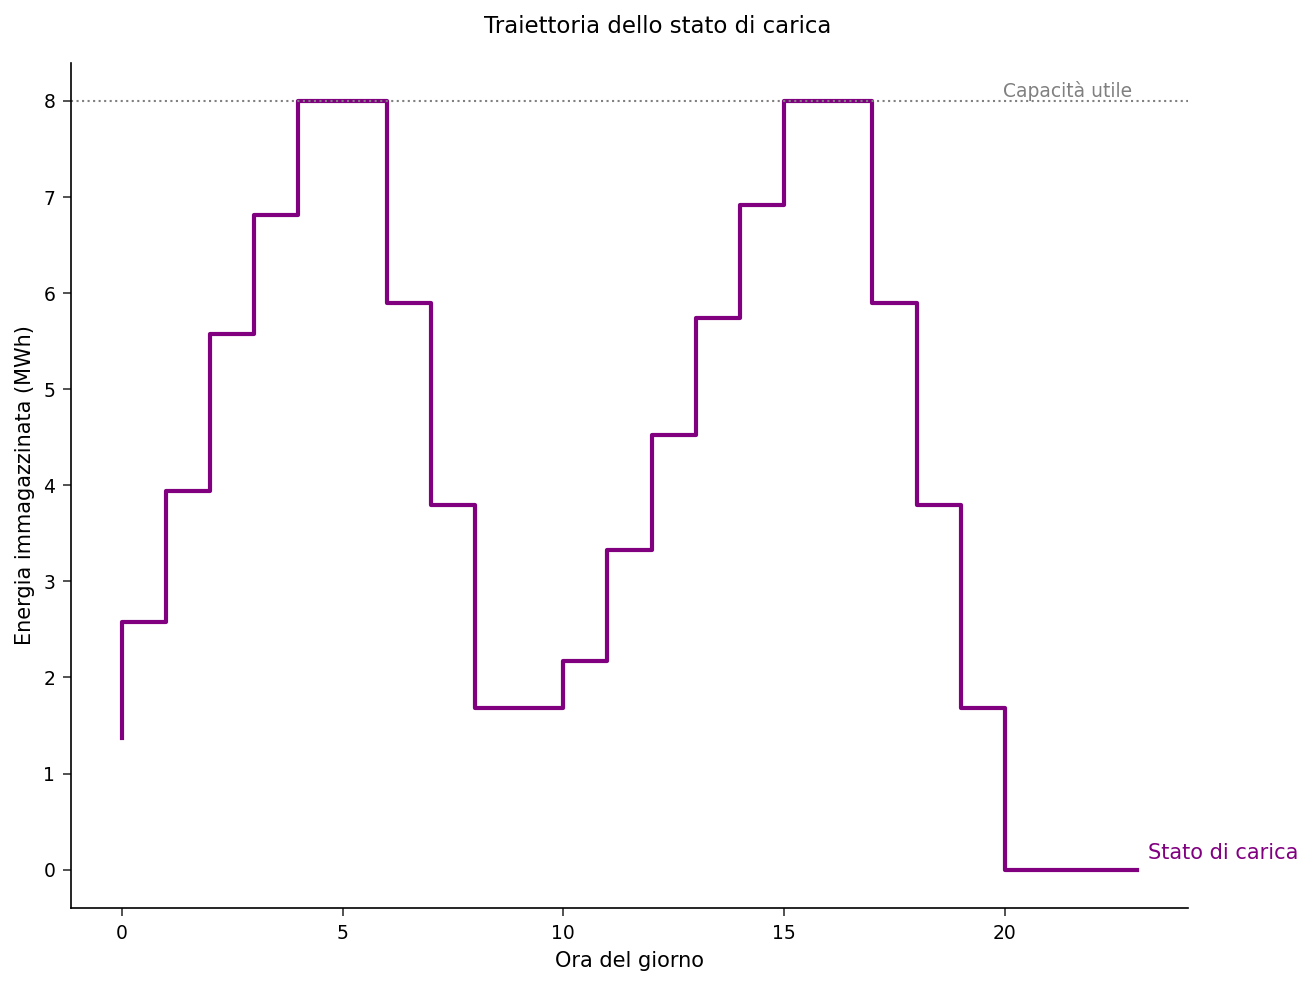

In [9]:
PROCEDURA SGPLOT DATI=dispatch;
    STEP x=hour y=soc_mwh / LINEATTRS=(color=purple thickness=2)
        curvelabel="Stato di carica";
    REFLINE 8 / AXIS=y LINEATTRS=(color=grey pattern=dot)
        ETICHETTA="Capacità utile";
    XAXIS ETICHETTA="Ora del giorno";
    YAXIS ETICHETTA="Energia immagazzinata (MWh)";
    TITOLO "Traiettoria dello stato di carica";
ESEGUIRE;


## 10. Prelievo dalla rete: prima vs dopo il dispacciamento

La linea arancione (prelievo dalla rete con la batteria) scende ben al di sotto del carico di riferimento tratteggiato durante la rampa serale (ore 18–21) — l'effetto di peak shaving che abbassa l'onere di potenza. Durante le finestre di carica notturne e di metà giornata sale, ma l'ottimizzatore lo limita a un tetto piatto di circa 3,43 MW che rimane *al di sotto* del picco di carico originale di 3,59 MW, così che la carica acquisti energia a basso costo senza stabilire un nuovo massimo fatturato.

                                  Indicatori chiave: arbitraggio e riduzione del picco                                  




NOTE: PROC SGPLOT data=dispatch

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


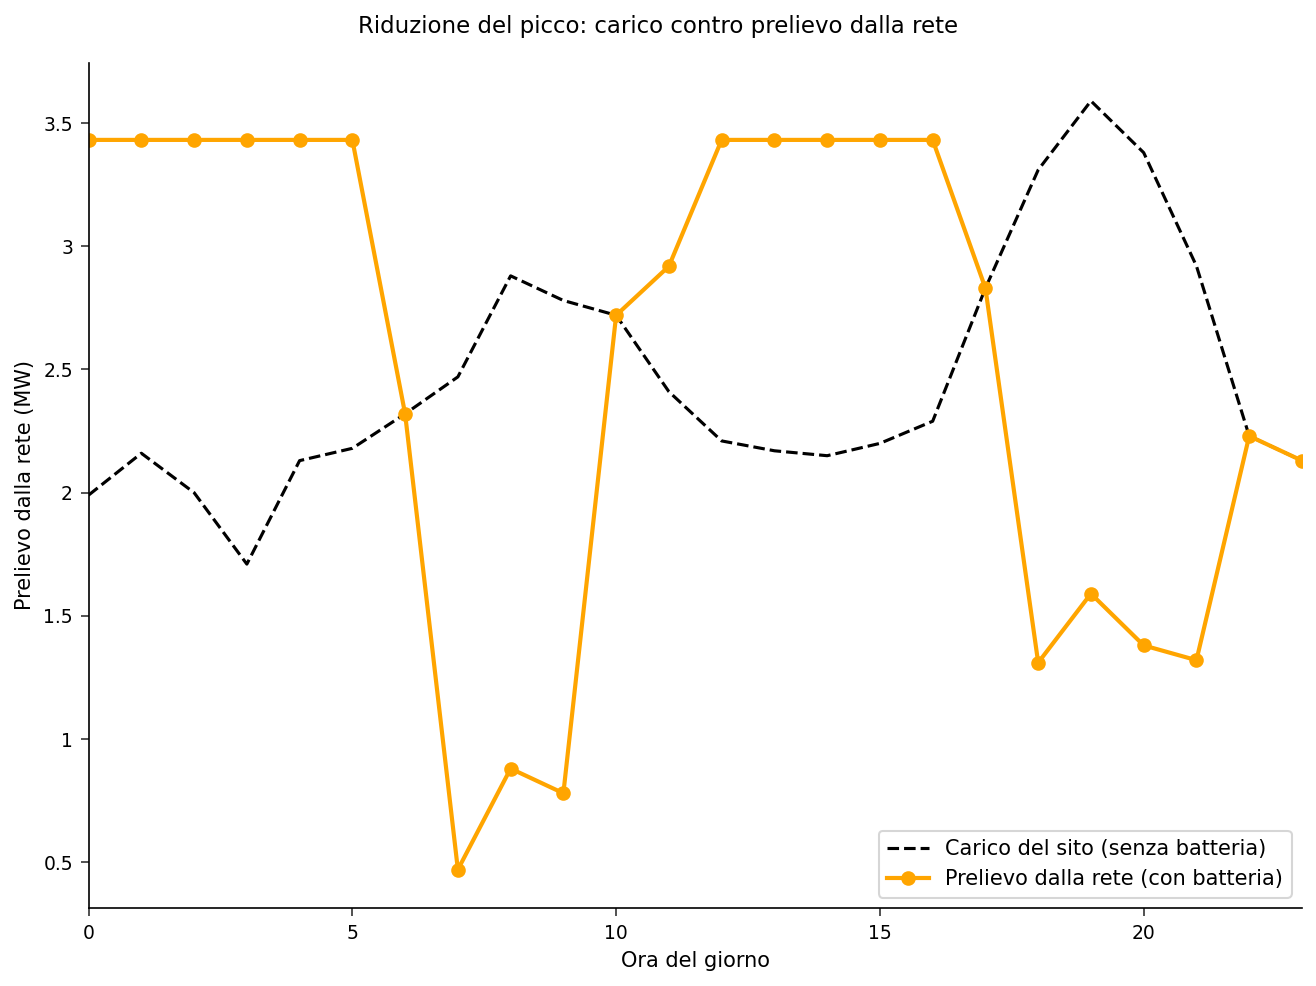

In [10]:
PROCEDURA SGPLOT DATI=dispatch;
    SERIES x=hour y=LOAD / LINEATTRS=(color=black pattern=dash)
        legendlabel="Carico del sito (senza batteria)";
    SERIES x=hour y=grid_mw / LINEATTRS=(color=orange thickness=2)
        MARKERS legendlabel="Prelievo dalla rete (con batteria)";
    XAXIS ETICHETTA="Ora del giorno";
    YAXIS ETICHETTA="Prelievo dalla rete (MW)";
    TITOLO "Riduzione del picco: carico contro prelievo dalla rete";
ESEGUIRE;


## Interpretazione e passi successivi

**Cosa ha deciso il modello.** Con l'efficienza di ciclo completo che tassa ogni ciclo, l'ottimizzatore ha comunque trovato un valore chiaro: ha riempito la batteria durante le ore notturne più economiche, ha scaricato nel picco di prezzo mattutino (ore 7–9), ha ricaricato durante la valle di prezzo di metà giornata (ore 11–16) e ha scaricato di nuovo nel più ricco picco serale (ore 18–21). Significativamente, ha caricato a soli 1,0–1,7 MW anziché alla piena potenza di 2 MW durante il riempimento notturno — trattenendo la potenza in modo che il prelievo dalla rete aggiunto non spingesse mai l'importazione al di sopra del picco di carico della giornata. Lo stato di carica ha rispettato in ogni momento sia la capacità di 8 MWh sia il limite di potenza di 2 MW.

**Il business case.** Il costo energetico giornaliero è sceso da **\$2.903,78 a \$2.528,43** — **\$375,34 (12,9%)** di risparmio da arbitraggio — e il massimo di rete fatturato è sceso da **3,59 MW a 3,43 MW** (circa **0,16 MW**), riducendo di ulteriori **\$18,98** la voce dell'onere di potenza. Annualizzato su tutte le giornate operative più la riduzione ricorrente dell'onere di potenza, questo è il tipo di margine che sostiene un investimento in accumulo.

**Perché un LP è lo strumento giusto.** Le euristiche ("carica al di sotto del prezzo mediano, scarica al di sopra") ignorano le perdite di efficienza, l'accoppiamento della capacità tra le ore e il fatto che l'onere di potenza dipende da un singolo intervallo — caricherebbero a piena potenza di notte e *aumenterebbero* il picco fatturato, distruggendo il valore del peak shaving. PROC OPTMODEL cattura tutto questo in un unico modello dichiarativo e restituisce la pianificazione dimostrabilmente ottimale, che qui modera deliberatamente il tasso di carica per proteggere il picco.

**Estendere il modello.**

- **Orizzonti più lunghi / multi-giornata** — ampliare l'insieme degli indici `HOURS`; aggiungere limiti di ciclatura inter-giornaliera.
- **Incertezza sul prezzo** — risolvere l'LP su più scenari di prezzo e mediare la decisione della prima ora (una politica stocastica a scorrimento).
- **Degrado della batteria** — aggiungere un termine di penalità sul throughput o un vincolo sui cicli cumulativi per bilanciare l'arbitraggio con la vita dell'asset.
- **Risposta in frequenza / mercati della capacità** — introdurre vincoli di margine riservato in modo che la batteria possa cumulare i ricavi da servizi ancillari sopra l'arbitraggio.

Tutte queste sono modifiche incrementali allo stesso blocco OPTMODEL — la struttura qui stabilita si mantiene invariata.